# Project 3 - Lab 3 - Vehicle Trajectory Simulation with the Intelligent Driver Model (IDM)

In [29]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt

## Introduction to the Intelligent Driver Model (IDM)

In the previous labs, we visualized real-world driving data from the NGSIM dataset. We observed how vehicles follow each other — adjusting their speed and acceleration based on the vehicle ahead. But how can we **model** this behavior mathematically?

The **Intelligent Driver Model (IDM)** is one of the most widely used car-following models in transportation engineering. Developed by Treiber, Hennecke, and Helbing (2000), the IDM describes how a driver accelerates or decelerates based on:
- Their current speed
- The gap (distance) to the vehicle ahead
- The speed difference (approaching rate) relative to the vehicle ahead

This model is used extensively in traffic simulation software, autonomous vehicle development, and transportation planning.

## The IDM Equations

The IDM computes the acceleration of the follower vehicle using the following equation:

$$\frac{dv}{dt} = a \left[1 - \left(\frac{v}{v_0}\right)^\delta - \left(\frac{s^*(v, \Delta v)}{s}\right)^2\right]$$

Where $s^*(v, \Delta v)$ is the **desired minimum gap**:

$$s^*(v, \Delta v) = s_0 + v \cdot T + \frac{v \cdot \Delta v}{2\sqrt{a \cdot b}}$$

Let's understand each parameter:

| Parameter | Symbol | Description | Typical Value |
|-----------|--------|-------------|---------------|
| Desired velocity | $v_0$ | Speed the driver wants to travel at in free flow | 30 m/s |
| Minimum spacing | $s_0$ | Minimum gap between vehicles when stopped | 2 m |
| Desired time headway | $T$ | Desired time gap to the leader | 1.5 s |
| Maximum acceleration | $a$ | Maximum comfortable acceleration | 1.0 m/s² |
| Comfortable deceleration | $b$ | Comfortable braking deceleration | 1.5 m/s² |
| Acceleration exponent | $\delta$ | Controls how acceleration decreases with speed | 4 |

Take a moment to think about these parameters. How would changing each one affect driving behavior?

Write here your thoughts:
1. What happens if the desired velocity $v_0$ increases? 
2. What happens if the time headway $T$ increases?
3. What happens if comfortable deceleration $b$ decreases?




1. Make the overall velocity decrease.
2. It will increase by a factor of T
3. Velocity would increase.


## Step 1: Define the IDM Acceleration Function

First, we need to write a Python function that computes the IDM acceleration. This function takes the current state of the follower vehicle and the leader vehicle, along with the model parameters, and returns the acceleration.

Remember from your math courses: a function takes inputs and produces an output. In Python, we define functions using `def`.

In [30]:
# Define the IDM acceleration function
# The function should take the following inputs:
#   v      : current speed of the follower vehicle (m/s)
#   s      : current gap distance between leader and follower (m)
#   delta_v : speed difference = follower speed - leader speed (m/s)
#   v0     : desired velocity (m/s)
#   s0     : minimum spacing (m)
#   T      : desired time headway (s)
#   a      : maximum acceleration (m/s^2)
#   b      : comfortable deceleration (m/s^2)
#   delta  : acceleration exponent

def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):
    # Step 1: Calculate the desired minimum gap s_star
    # s_star = s0 + v * T + (v * delta_v) / (2 * sqrt(a * b))
    
    s_star = s0 + v * T + (v * delta_v) / (2 * sqrt(a * b))
    
    # Step 2: Calculate the acceleration using the IDM equation
    # acceleration = a * [1 - (v/v0)^delta - (s_star/s)^2]
    
    acceleration = a * (1 - (v / v0)**delta - (s_star / s)**2)

    
    return acceleration

Let's test our function with a simple example to make sure it works correctly.

In [31]:
# Test the IDM function with sample values
# A follower traveling at 20 m/s, with a gap of 25 m, approaching the leader at 2 m/s

# Define parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a = 1.0    # maximum acceleration (m/s^2)
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Test case
test_v = 20        # follower speed
test_s = 25        # gap distance
test_delta_v = 2   # follower is faster than leader by 2 m/s

# Call the function and print the result
test_acc = idm_acceleration(test_v, test_s, test_delta_v, v0, s0, T, a, b, delta)
print(f"IDM Acceleration: {test_acc:.4f} m/s²")

# Think about: does this value make sense? The follower is approaching the leader, so should it accelerate or decelerate?

IDM Acceleration: -2.9348 m/s²


## Step 2: Set Up the Simulation

Now that we have our IDM function, we need to simulate a vehicle following scenario over time. To do this, we will use **Euler's method** — a simple numerical integration technique you may have seen in your math or physics courses.

The idea is simple: at each small time step $dt$, we update the vehicle's state:
- New acceleration = IDM function output
- New speed = old speed + acceleration × dt
- New position = old position + speed × dt

We will simulate a follower vehicle tracking a leader vehicle. The leader's trajectory will come from the NGSIM data we explored in Lab 2.

In [32]:
# Load the NGSIM data to get the leader vehicle trajectory
ngsim_data = pd.read_csv('NGSIM.csv')

# Select a trajectory pair
trajectory_number = 1
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

# Extract the leader's position and speed over time
time_data = data_subset['Time'].values
leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# What is the time step in our data?
dt = 0.1

## Step 3: Run the IDM Simulation

Now let's run the simulation! We will loop through each time step, compute the IDM acceleration, and update the follower's speed and position.

We will initialize the follower at the same position and speed as recorded in the NGSIM data.

In [33]:
# Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)
sim_position = np.zeros(n_steps)   # simulated follower position
sim_speed = np.zeros(n_steps)      # simulated follower speed
sim_acc = np.zeros(n_steps)        # simulated follower acceleration

print(n_steps)
print(sim_speed)

# Set initial conditions from the NGSIM data
sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]

print(sim_position)

841
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [44]:
# Run the simulation using a for loop
# At each time step i:
#   1. Calculate the gap: s = leader_position[i] - sim_position[i]
#   2. Calculate the speed difference: delta_v = sim_speed[i] - leader_speed[i]
#   3. Calculate IDM acceleration using our function
#   4. Update speed: sim_speed[i+1] = sim_speed[i] + acceleration * dt
#   5. Update position: sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

for i in range(n_steps - 1):
    # Step 1: Calculate the gap distance
    gap = leader_position[i] - sim_position[i]
    
    # Make sure gap is positive (safety check)
    gap = max(leader_position[i] - sim_position[i], 0.1)
    
    # Step 2: Calculate speed difference (positive means follower is faster)
    delta_v = sim_speed[i] - leader_speed[i]
    
    # Step 3: Calculate IDM acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)
    
    # Step 4 & 5: Update speed & position (make sure speed doesn't go negative)
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt, 0)  # speed cannot be negative
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt
    
    print(i)

print("Simulation complete")

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

## Step 4: Visualize the Simulation Results

Now comes the exciting part — let's visualize our simulation and compare it against the real NGSIM data! This will help us understand how well the IDM captures real driving behavior.

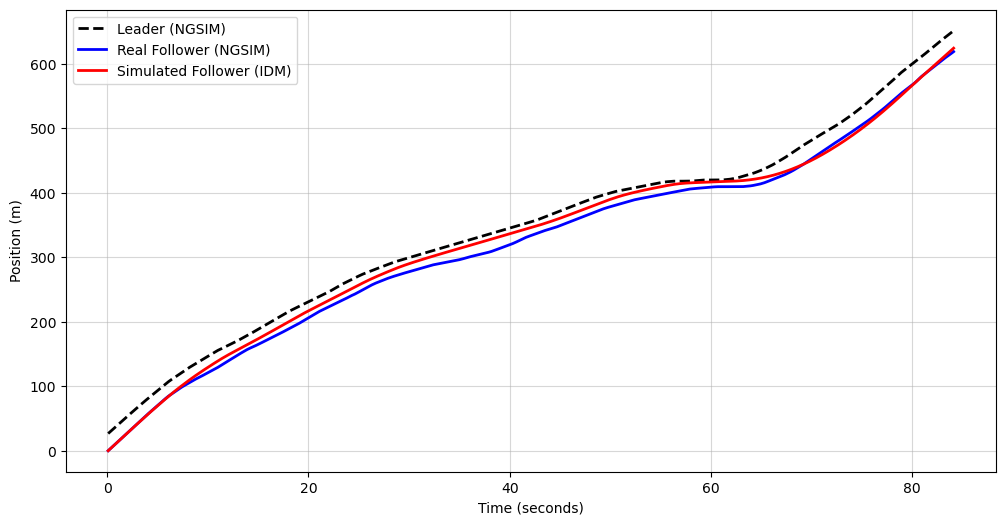

In [45]:
plt.figure(figsize=(12, 6))

plt.plot(time_data, leader_position, 'k--', linewidth = 2, label = 'Leader (NGSIM)') 
plt.plot(time_data, data_subset['follower_position(m)'].values, 'b-', linewidth = 2, label = 'Real Follower (NGSIM)') #this plots the actual follower position in my NGSIM data
plt.plot(time_data, sim_position, 'r-', linewidth = 2, label = 'Simulated Follower (IDM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()


## Step 5: Analysis of Simulation Results

Look at the plots you just created and analyze the results. Write your observations below:

1. How well does the IDM simulation match the real NGSIM data for position? Pretty well, but there are small gaps like where acceleration / deceleration changes. Not perfect, but it is close
   
2. How well does the IDM simulation match the real data for speed? Also matches pretty well, there is slight differences
   
3. Where do you see the biggest differences between simulation and reality? Ideal diver behavior, delays or extertnal factors such as traffic or road conditions.
   

## Step 6: Experimenting with IDM Parameters

One of the most powerful aspects of simulation is the ability to explore "what-if" scenarios. Let's see how changing the IDM parameters affects driving behavior.

Below, you will re-run the simulation with different parameter values and visualize the results.

In [8]:
# Experiment 1: Change the desired time headway T
# Try three different values: T = 0.5s (aggressive), T = 1.5s (normal), T = 3.0s (cautious)
# Run the simulation for each and plot the position trajectories on the same graph




    # Initialize arrays
 
    
    # Run simulation with this T value

    
    # Plot this trajectory
    # use plt.plot to add this trajectory to the figure
    

# Add labels, title, legend



In [10]:
# Experiment 2: Change the desired velocity v0
# Try three different values: v0 = 15 m/s (slow), v0 = 30 m/s (normal), v0 = 45 m/s (fast)
# Run the simulation for each and plot the speed profiles on the same graph



Write your observations about how parameter changes affect the simulation:
1. How does increasing the time headway T change the follower behavior?
   
2. How does changing the desired velocity v0 affect the results?
   
3. Which parameter do you think has the biggest impact on safety? Why?
   

## Step 7: Trajectory Heatmap Visualization

Let's combine what we learned in Lab 2 about heatmaps with our simulation results. We will create a trajectory plot colored by speed for the simulated vehicle.

## Wrap Up

In this lab, you have learned:
1. The mathematical foundation of the Intelligent Driver Model (IDM)
2. How to implement a car-following simulation in Python
3. How to use Euler's method for numerical integration
4. How to compare simulation results against real-world data
5. How changing model parameters affects driving behavior

These skills are directly applicable to transportation engineering practice, where simulation models are used to evaluate highway designs, traffic signal timing, and the impact of autonomous vehicles on traffic flow.